# Simple Grid World: Eligibility Traces (Linear Approximation With Fourier Basis Features)

## Installation and Setup

You need:
* Gymnasium (see [Installation Instructions](../common/Setup_Gymnasium.ipynb))
* Patched `gym-classics-1.0.0+internal.rev1` or later (see [Installation instructions](../common/Setup_patched_gym_classics.ipynb))

In [1]:
import numpy as np
np.set_printoptions(precision=2)

In [2]:
import gymnasium as gym
import gym_classics
gym_classics.register('gymnasium')

## Define a Grid World 

In [3]:
gym_env = gym.make('LMaze-v0')

env = gym_env.unwrapped

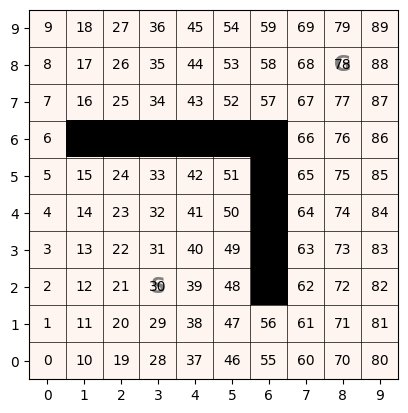

In [4]:
env.image()

## Setting up the Approximation

Helper to plot a solution given the learned weight vector $\mathbf{w}$.

In [5]:
from gym_classics.algorithms.linear_approximation import semi_gradient_Sarsa_0, state_features, state_action_features, q_hat, transformation_fourier_basis
from gym_classics.algorithms.policy import greedy_policy

# helper to visualize the learned policy and value function 
def plot_w(w, title=None, clim=(-1,1)):
    Q = np.array([[q_hat(s, a, w,env) for a in range(env.action_space.n)] for s in range(env.observation_space.n)])
    V = np.max(Q, axis=1)
    pol = np.argmax(Q, axis=1)
    env.image(V, policy=pol, title=title, clim=clim )
    
    return Q, V, pol

In [10]:
trans_fb = transformation_fourier_basis(min = np.array([0,0]), max = env.dims, order=2)

# overwrite state_features for the semi-gradient Sarsa implementation with Fourier basis features
def state_features(s, env):
    return trans_fb(env.id2state(s))

gym_classics.algorithms.linear_approximation.state_features = state_features

## Define $Sarsa(\lambda)$ 

Add eligibility traces as a vector $z$ that accumulates how much each weight needs to be adjusted when a reinforcement event (reward) happens.



In [11]:
from tqdm import tqdm

def semi_gradient_Sarsa_lambda(
    env,
    n,
    epsilon,
    alpha,
    gamma,
    lam,
    w=None,
    max_episode_length=1000,
    verbose=True
):
    """
    Semi-gradient SARSA(lambda): on-policy control with linear function approximation
    and eligibility traces.

    Parameters
    ----------
    env : GymClassicsBaseEnv
        Episodic environment used to generate experience.
    n : int
        Number of episodes.
    epsilon : float
        Exploration rate for epsilon-greedy policy.
    alpha : float
        Step size.
    gamma : float
        Discount factor.
    lam : float
        Trace-decay parameter lambda in [0, 1].
    w : array-like or None
        Initial weights. If None, initializes to zeros.
    max_episode_length : int
        Maximum number of steps per episode.
    verbose : bool
        Whether to print step-by-step diagnostics.

    Returns
    -------
    w : np.ndarray
        Learned weight vector.
    """

    #assert isinstance(env, GymClassicsBaseEnv), "env must be an instance of GymClassicsBaseEnv"
    assert alpha > 0 and alpha <= 1, "alpha must be in (0,1]"
    assert gamma >= 0 and gamma <= 1, "gamma must be in [0,1]"
    assert lam >= 0 and lam <= 1, "lambda must be in [0,1]"
    assert epsilon >= 0 and epsilon <= 1, "epsilon must be in [0,1]"
    assert n > 0, "number of episodes must be positive"
    assert max_episode_length > 0, "max episode length must be positive"

    if w is None:
        w = np.zeros(1 + state_features(0, env).shape[0] * env.action_space.n)

    def epsilon_greedy_action(state, epsilon):
        if np.random.rand() < epsilon:
            return env.action_space.sample()
        q_values = [q_hat(state, a, w, env) for a in range(env.action_space.n)]
        return np.argmax(q_values)

    for episode in tqdm(range(n), desc="Semi-Gradient SARSA(lambda)", disable=verbose):
        state, _ = env.reset()
        action = epsilon_greedy_action(state, epsilon)

        # eligibility trace vector, same size as w
        z = np.zeros_like(w)
        Q_old = 0

        done = False
        i = 0

        while not done and i < max_episode_length:
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            # current feature vector for (state, action)
            x = state_action_features(state, action, env)

            # update trace
            z = gamma * lam * z + (1 - alpha * gamma * lam * np.dot(z, x)) * x

            if terminated:
                delta = reward - q_hat(state, action, w, env)
            else:
                next_action = epsilon_greedy_action(next_state, epsilon)
                delta = reward + gamma * q_hat(next_state, next_action, w, env) - q_hat(state, action, w, env)

            # semi-gradient weight update
            Q = q_hat(state, action, w, env)
            Q_prime = q_hat(next_state, next_action, w, env) if not terminated else 0            
            w += alpha * (delta + Q - Q_old) * z - alpha * (Q - Q_old) * x

            Q_old = Q_prime

            if verbose:
                if terminated:
                    print(
                        f"Episode {episode+1}, Step {i+1}: "
                        f"S={state}, A={action}, R={reward}, S'={next_state}, "
                        f"delta={delta}, z={z}, w={w}"
                    )
                else:
                    print(
                        f"Episode {episode+1}, Step {i+1}: "
                        f"S={state}, A={action}, R={reward}, S'={next_state}, A'={next_action}, "
                        f"delta={delta}, z={z}, w={w}"
                    )

            if done:
                break

            state = next_state
            action = next_action
            i += 1

    return w

## Compare Sarsa(0) with Sarsa($\gamma$)

Episode 1, Step 1: S=30, A=0, R=0.0, S'=31, w=[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Episode 1, Step 2: S=31, A=0, R=0.0, S'=32, w=[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Episode 1, Step 3: S=32, A=1, R=0.0, S'=41, w=[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Episode 1, Step 4: S=41, A=0, R=0.0, S'=42, w=[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Episode 1, Step 5: S=42, A=2, R=0.0, S'=41, w=[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Episode 1, Step 6: S=41, A=0, R=0.0, S'=42, w=[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Episode 1, Step 7: S=42, A=0, R=0.0, S'=

Episode 1, Step 422: S=36, A=0, R=0.0, S'=36, w=[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Episode 1, Step 423: S=36, A=0, R=0.0, S'=36, w=[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Episode 1, Step 424: S=36, A=0, R=0.0, S'=36, w=[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Episode 1, Step 425: S=36, A=0, R=0.0, S'=36, w=[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Episode 1, Step 426: S=36, A=0, R=0.0, S'=36, w=[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Episode 1, Step 427: S=36, A=0, R=0.0, S'=36, w=[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Episode 1, Step 428: S=36, A

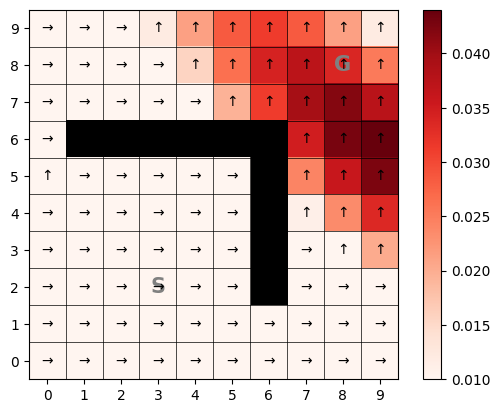

In [12]:
w = semi_gradient_Sarsa_0(env, n=1, epsilon=0.3, alpha=0.01, gamma=1, max_episode_length = 10000, verbose=True)
Q, V, pol = plot_w(w, clim = None)

Episode 1, Step 1: S=30, A=0, R=0.0, S'=31, A'=3, delta=0.0, z=[ 1.00e+00  8.09e-01  3.09e-01  5.88e-01  6.12e-17 -5.88e-01 -3.09e-01
 -8.09e-01 -1.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00
  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00
  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00
  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00
  0.00e+00  0.00e+00], w=[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Episode 1, Step 2: S=31, A=3, R=0.0, S'=22, A'=1, delta=0.0, z=[ 1.98e+00  8.01e-01  3.06e-01  5.82e-01  6.06e-17 -5.82e-01 -3.06e-01
 -8.01e-01 -9.90e-01  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00
  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00  0.00e+00
  0.00e+00  0.00e+00  0.00e+00  0.00e+00  5.82e-01 -3.06e-01  5.82e-01
 -3.06e-01 -9.42e-01 -3.06e-01 -9.42e-01 -8.01e-01  0.00e+00  0.00e+00
  0.00e+00  0.00e+00], w=

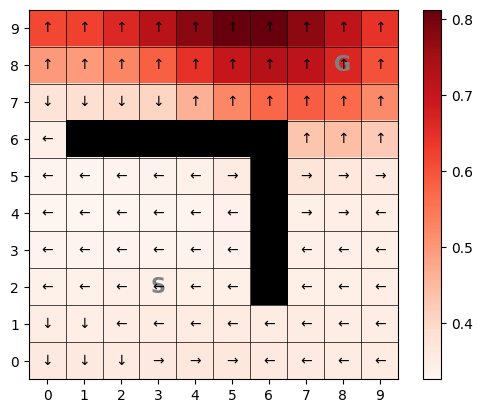

In [13]:
w = semi_gradient_Sarsa_lambda(env, n=1, epsilon=0.3, alpha=0.01, gamma=1, lam=0.99, max_episode_length = 10000, verbose=True)
Q, V, pol = plot_w(w, clim = None)

We use a very high lambda (close to MC). The algorithm is able to update in the last step more weights.

## Run Sarsa($\gamma$)

This implementation also keeps return histories.

In [14]:
from gym_classics.algorithms.eligibility_traces import semi_gradient_Sarsa_lambda

gym_classics.algorithms.eligibility_traces.state_features = state_features

w, history = semi_gradient_Sarsa_lambda(env, n=100, epsilon=0.1, alpha=0.01, gamma=1, lam=0.5, max_episode_length = 1000, verbose=False, history = True)


Semi-Gradient SARSA(lambda):   0%|          | 0/100 [00:00<?, ?it/s]

Semi-Gradient SARSA(lambda): 100%|██████████| 100/100 [00:06<00:00, 14.49it/s]


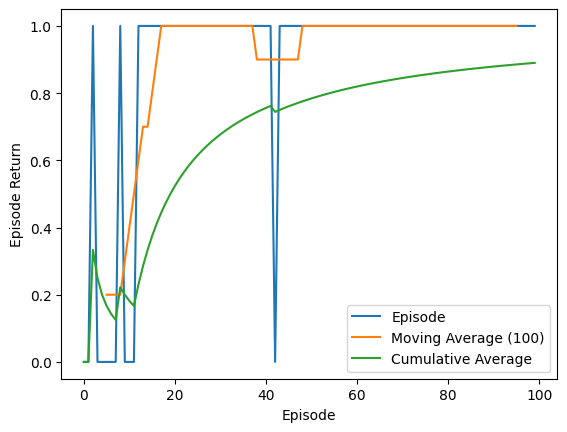

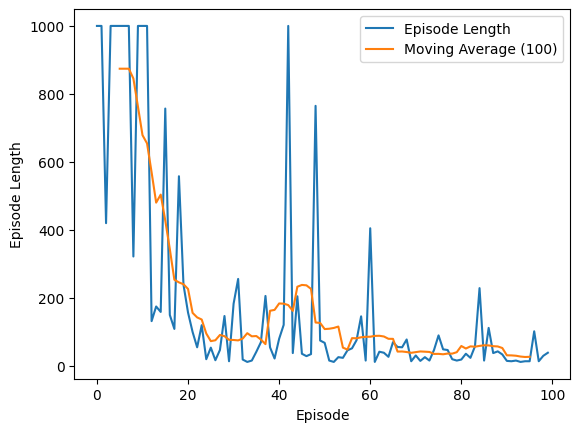

In [15]:
from gym_classics.performance import plot_returns, plot_ep_lens
plot_returns(history['returns'], window_size= 10)
plot_ep_lens(history['ep_lens'], window_size= 10)

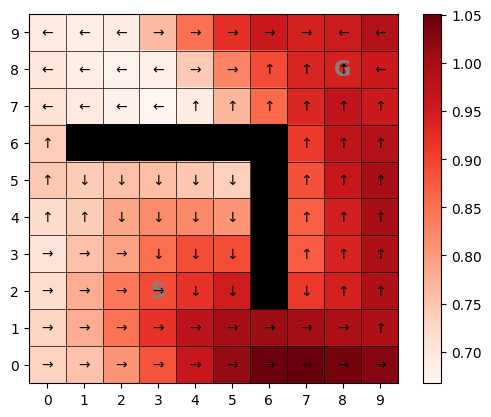

In [16]:
Q, V, pol = plot_w(w, clim = None)

An example episode for the learned policy.

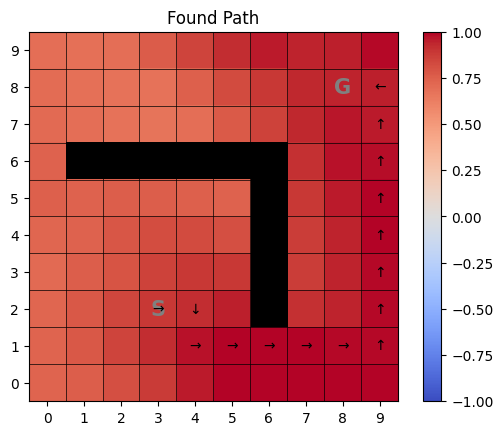

In [17]:
from gym_classics.algorithms.monte_carlo_methods import sample_episode

path = sample_episode(env, policy=pol, max_len=100)
env.image(V, policy=pol, episode=path, title='Found Path', clim=(-1,1))

## Inspect the Learned Weights and Value Function

In [18]:
w

array([ 0.78,  0.  ,  0.01, -0.14, -0.07, -0.02,  0.03,  0.03, -0.07,
        0.05,  0.12, -0.08, -0.04, -0.03, -0.01,  0.02, -0.08, -0.02,
        0.06, -0.1 , -0.02, -0.09, -0.03, -0.03, -0.04, -0.03,  0.03,
       -0.12,  0.01, -0.03,  0.02, -0.02, -0.03,  0.  ,  0.  ,  0.  ,
        0.  ])

We can look at the learned Q values and the final value function.

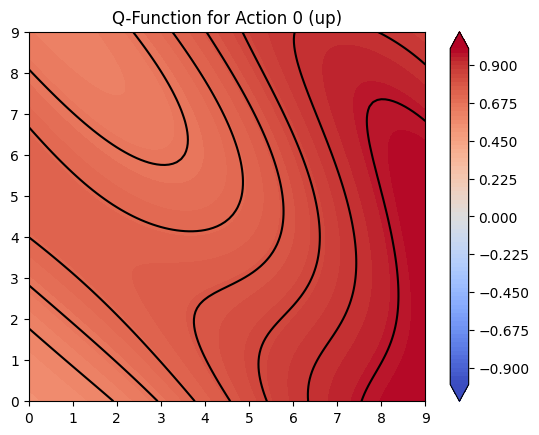

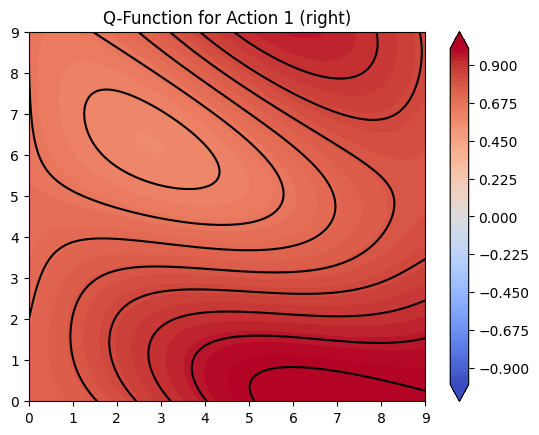

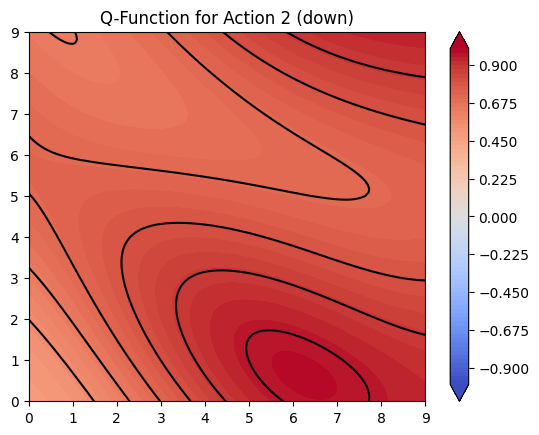

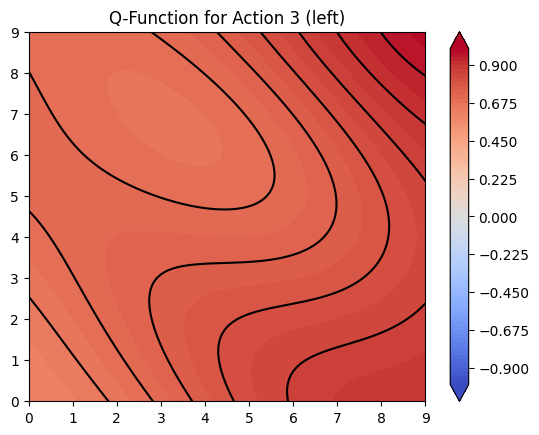

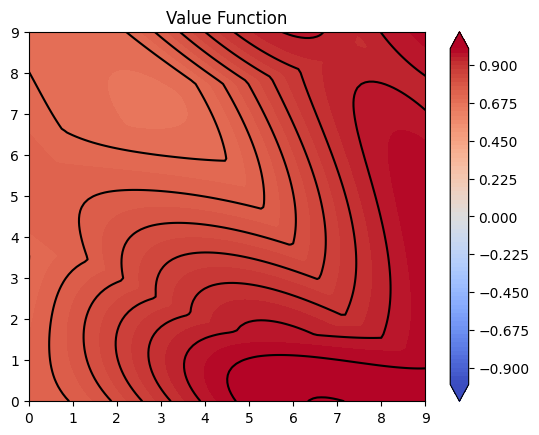

In [20]:
from matplotlib import pyplot as plt

def q_hat_grid(x, y, a, w):
    x_s = trans_fb(np.array([x, y]))
    sf_len = len(x_s) -1
    active_weights = [0] + list(range(a*sf_len+1, a*sf_len+sf_len+1))
    return np.dot(w[active_weights], x_s)

x = np.linspace(0, env.dims[0]-1, 100)
y = np.linspace(0, env.dims[1]-1, 100)
X, Y = np.meshgrid(x, y)

# plot the Q-function for each action
for a in range(env.action_space.n):
    Z = np.array([q_hat_grid(x, y, a, w) for x, y in zip(np.ravel(X), np.ravel(Y))]).reshape(X.shape)
    plt.contourf(X, Y, Z, cmap='coolwarm', levels=list(np.linspace(-1, 1, 81)), extend='both')
    plt.colorbar()
    plt.title(f'Q-Function for Action {a} ({env.id2action(a)})')
    plt.contour(X, Y, Z, colors='black') # Contour lines
    plt.show()
    
# plot the value function
Z = np.array([np.max([q_hat_grid(x, y, a, w) for a in range(env.action_space.n)]) for x, y in zip(np.ravel(X), np.ravel(Y))]).reshape(X.shape)
plt.contourf(X, Y, Z, cmap='coolwarm',levels=np.linspace(-1, 1, 81), extend='both')
plt.colorbar()
plt.title('Value Function')
plt.contour(X, Y, Z, colors='black') # Contour lines
plt.show()


&copy; 2025 [Michael Hahsler](http://michael.hahsler.net). 
This work is openly licensed under [Creative Commons Attribution-ShareAlike 4.0 International (CC BY-SA 4.0) License](https://creativecommons.org/licenses/by-sa/4.0/)

![CC BY-SA 4.0](https://licensebuttons.net/l/by-sa/3.0/88x31.png)